# Photometric Data Reduction

    Created: Zachary Lane, June 2024
    Edited: Zachary Lane, July 2024
    Last Edited: C.Clare Worley, August 2024

This notebook is aimed at teaching students about photometric data reduction.

Work your way through the notebook, **reading each code cell carefully before running it**. This is a live document, all the cells can easily be edited, and re-run any time you wish. Ask questions if you need to.

In [ ]:
import os # A module for communicating with the operating system e.g. commands and files
import glob # A module for searching data files
import subprocess
import requests
from io import StringIO
from copy import deepcopy # A module for copying objects
import matplotlib.pyplot as plt # A plotting library
import numpy as np # Numerical Python, great for vectorised equations
import pandas as pd # DataFrames for organising data/tables

from astropy.io import fits # Astronomy Python for opening ".fits" files
from astropy.stats import SigmaClip, sigma_clipped_stats, sigma_clip
from astropy.time import Time
from astropy.wcs import WCS
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle

from photutils.background import Background2D, MedianBackground # Fitting background surfaces to astronomical images
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry, CircularAnnulus, SkyCircularAperture
from photutils.aperture import ApertureStats

from astropy.wcs import FITSFixedWarning

import warnings # To ignore our problems
warnings.filterwarnings('ignore', category=FITSFixedWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning) #Shhhhh, ignore our problems

%matplotlib inline

# Task Overview

Last week you learnt how to reduce a 'nice' set of data. This week you are digging deeper to extract the best science data possible from raw and calibration data that are not so 'nice'.
</br></br>

You will be given a set of data to reduce that has been observed for a specific science goal. There are five datasets from which you can choose:

- Planet (Jupiter)
- Transient (Nova)
- Comet (C\2019-E3)
- Galaxy (NGC1300)
- Globular Cluster (47 Tuc)

For each dataset there are a unique set of problems contained in the reduction and post-processing stage. 
</br></br>


**Use the code that you developed in Lab 3 to:**
1. organise the files
2. generate the master darks
3. generate the master flat
4. reduce the raw data into science images
</br></br>

**Then ...**
1. If it worked first time, how do the science images look? How can you improve them?
2. If it didn't work first time, where did it go wrong?
3. How do the master and individual calibrations look? Some look better than others?
4. Compare your raw to your calibrations to your science images. Are there artifacts you can work on removing?
</br></br>

For each issue you come across in the data reduction you should document the following:

- What is the problem?
- How did you find it?
- How does this affect the raw, calibration and/or science images?
- How did/would you solve it?

These notes make up your data reduction log which you will submit at the end of the lab. There is a template on LEARN to get you started. These are an INFORMAL record of what you tried. No formal writing style is required. Note that inappropriate comments will result in deducted marks.
</br></br>

Each dataset has an associated science measurement to be carried out after you have reduced the data. **This is an additional exercise.** Only attempt this when you have found and solved all the issues in the data reduction.

## Marking Guide ##
1. You do NOT need to do the science measurement to get full marks.
2. You do NOT need to have extracted perfect science data to get full marks.
3. You DO need to have dug into the data and explored different ways to improve the extraction.
4. You DO need to have identified problems in the data.
5. You DO need to have documented your process as an INFORMAL log of what you have tried to do.


## What to submit? ##
At the end of the lab:
1. Submit your data reduction log
2. Submit your best effort reduced science data


## Can I talk to the tutors? ##
Absolutely. Talk to the tutors, talk to your neighbours. Data reduction is a collaborative process. Always ask for help. 
</br></br></br>

---

### Reminder: Image Reduction formula

We will be reducing our images based on the following formula...

$$I_f^{} = \frac{I_r^{} - {\rm master}[D_I^{}]}{{\rm master}[{\rm cal.}(F_I^{} - D_F^{})]} - B$$

Where:

$I_f$ - final image

$I_r$ - raw image

$D_I$ - Darks with the same exposure time as the raw image

$F_I$ - Flats with the same filter as the raw image

$D_F$ - Darks with the same exposure time as the flat

$B$ - Background surface

</br></br>

---

# Option 1: Planet - Jupiter

The science goal is to determine the rotation rate of Jupiter by tracking its giant red spot. The theoretical value for this is 9 hours and 56 minutes.

To meet this science goal requires multiple observations. **Therefore there are multiple raw images you need to reduce.**
The raw and calibration files for this option are located on the macdiarmid server: ASTR211/2024_Lab_Files/Advanced_Phot_Reduction_Lab/Jupiter/

All data must be reduced and all problems within the data must be identified and resolved **before doing the science measurement**. 

Discuss with the tutor if you think you are done with the data reduction

</br>

**Additional exercise: hints on doing the science measurement:**

Use the radius of the planet (or a scaled version) and the latitude of the spot to find how far the spot has moved. The planet is not necessarily the same size on the detector with each subsequent exposure due to atmosphere conditions.

Potentially useful equations:
- $r_{\rm eff.}^{} = r \times \cos{\theta_{\rm lat.}^{}}$ (sphere)
- $d_{\rm chord} = 2r \times \sin{(\frac{\theta_{\rm rot.}^{}}{2})}$ (geometry)
- $T = \frac{2 \pi \Delta t}{\Delta \theta}$ (period)

</br></br>

---


In [31]:
import os # A module for communicating with the operating system e.g. commands and files
import glob # A module for searching data files
import matplotlib.pyplot as plt # A plotting library
import numpy as np # Numerical Python, great for vectorised equations
import scipy # Scientific Python, great for algorithms and optimisation
import pandas as pd # DataFrames for organising data/tables
from astropy.io import fits # Astronomy Python for opening ".fits" files
from photutils.background import Background2D, MedianBackground # Fitting background surfaces to astronomical images
from copy import deepcopy # A module for copying objects
import warnings # To ignore our problems
warnings.filterwarnings('ignore', category=RuntimeWarning) #Shhhhh, ignore our problems


%matplotlib inline

# bringing in our data from macdiarmid

folder = '//macdiarmid/ASTR211/2024_Lab_Files/Advanced_Phot_Reduction_Lab/Jupiter/' # This is the direct folder with the files

# Goes through and finds each file in a designated folder

files = [folder + file for file in os.listdir(folder) if '.fit' in file]

print()
# Goes through and finds each file with a specific pattern in the folder, alternate method (puts in a list)
# This method is architecture dependent (e.g. the order for a MacOs M3 will be different to a Windows HP)
darks = []
flats = []
lights = []

files = glob.glob(folder + '*.fit*')

for file in files:
    hdul = fits.open(file)
    if 'IMAGETYP' not in hdul[0].header.keys():
        darks.append(file)
    else:
        img_type = hdul[0].header['IMAGETYP']
        if img_type == "Dark Frame":
            darks.append(file)
        elif img_type == "Flat Field":
            flats.append(file)
        else:
            lights.append(file)
        
print(f"Darks: {len(darks)}")
print(f"Flats: {len(flats)}")
print(f"Lights: {len(lights)}")


Darks: 33
Flats: 83
Lights: 76


Methane 18
filter type Methane


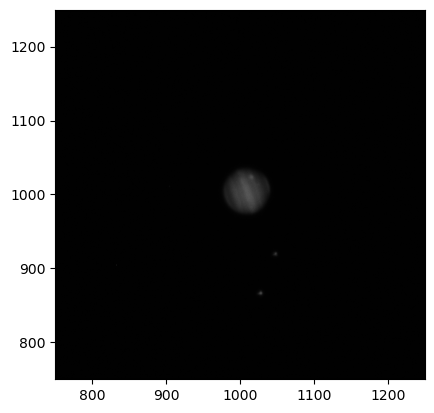

<Figure size 640x480 with 0 Axes>

In [77]:
# now to check the exposure times of each of our image types
"""
for dark in darks:
    hdul = fits.open(dark)
    header = hdul[0].header
    print(header["EXPTIME"])
    
print("\n"*3, "FLATS \n")    
    
for flat in flats:
    hdul = fits.open(flat)
    header = hdul[0].header
    print(header["EXPTIME"])    
    
print("\n"*3, "LIGHTS \n")  
    
for light in lights:
    hdul = fits.open(light)
    header = hdul[0].header
    print(header["EXPTIME"])
    """

def exposure_dict(img_list):
    img_dict = {}
    for img in img_list:
        hdul = fits.open(img)
        header = hdul[0].header
        time = header["EXPTIME"]
        if time in img_dict.keys():
            img_dict[time].append(img)
        else:
            img_dict[time] = [img]
    return img_dict

       
filters = {}

for light in lights:
    hdul = fits.open(light)
    header = hdul[0].header
    filter_type = header["FILTER"]
    if filter_type in filters.keys():
        filters[filter_type].append(light)
    else:
        filters[filter_type] = [light]
        
for key, value in filters.items():
    print(key, len(value))
    
# lets show one of each filter to check which pics the spot up the best    
for filter_type in filters.keys():
    filename = filters[filter_type][0]
    hdul = fits.open(filename)
    data = hdul[0].data
    print("filter type", filter_type)
    plt.imshow(data, cmap = 'gray')
    plt.xlim(750, 1250)
    plt.ylim(750,1250)
    plt.figure()

In [82]:
# now we know we only want methane filtered images we can throw the other filters away
lights = filters["Methane"]

exp_dict = exposure_dict(lights)
for key, value in exp_dict.items():
    print(key, len(value))
    
# we can throw away the two 120 second exposures
#lights = exp_dict[0.1] + exp_dict[3.0] + exp_dict[0.05]

# lets examine one of each exposure to gauge their use
# exp_dict = exposure_dict(lights)
# for time in exp_dict.keys():
#     file = exp_dict[time][0]
#     print(time)
#     hdul = fits.open(file)
#     data = hdul[0].data
#     plt.imshow(data, cmap = 'gray')
#     plt.figure()
    
lights = exp_dict[3.0]
print(len(lights))





0.1 2
3.0 11
120.0 2
0.05 3
11


In [88]:
# lets now grab methane filtered flats
def filter_dict(img_list):
    img_dict = {}
    for img in img_list:
        hdul = fits.open(img)
        header = hdul[0].header
        time = header["FILTER"]
        if time in img_dict.keys():
            img_dict[time].append(img)
        else:
            img_dict[time] = [img]
    return img_dict

flat_filters = filter_dict(flats)
flats = flat_filters["Methane"]

# now to sort by exptime 
flat_exp = exposure_dict(flats)
for key, value in flat_exp.items():
    print(key, len(value))
    
# so we have 2 sets of flats one of exposure 3s and the other 4s
# well create a master dark for each

3.0 9
4.0 3


3 8
0.15 3
0.8 3
120.0 3
30.0 3
300.0 3
4.0 7
60.0 3


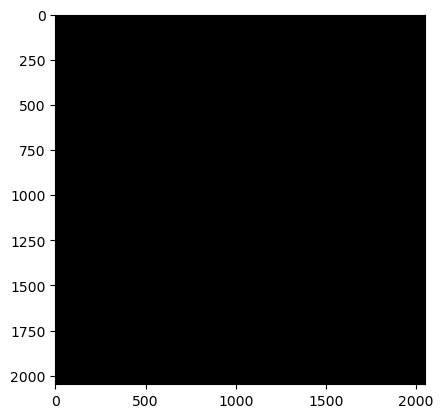

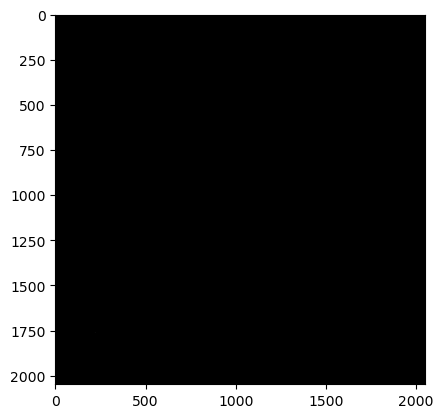

In [91]:
# now we have selected our lights its time to sort our darks out

# lets make a master dark for our lights

dark_dict = exposure_dict(darks)
for key, value in dark_dict.items():
    print(key, len(value))
    
# we have 8 3s darks, these will comprise our master dark for the lights
darks_data = []
list_dark_files = dark_dict[3]
for dark_file in list_dark_files:
    hdul = fits.open(dark_file)
    darks_data.append(hdul[0].data) # Append the data to the list
    hdul.close()

master_dark3 = np.median(darks_data, axis=0) # Median combine the darks


darks_data = []
list_dark_files = dark_dict[4.0]
for dark_file in list_dark_files:
    hdul = fits.open(dark_file)
    darks_data.append(hdul[0].data) # Append the data to the list
    hdul.close()

master_dark4 = np.median(darks_data, axis=0) # Median combine the darks


plt.imshow(master_dark4, cmap = 'gray')
plt.figure()
plt.imshow(master_dark3, cmap = 'gray')




7 3


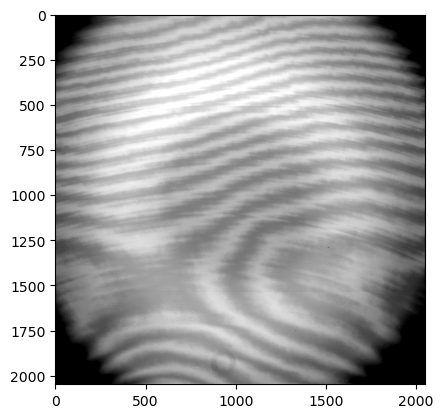

In [94]:
# Now we have our master darks we can go about making our flats


# first we check the median of each flat is within 24k-45k
good_flats = []
for flat in flats:
    hdul = fits.open(flat)
    flat_data = hdul[0].data # Append the data to the list
    hdul.close()
    median = np.median(flat_data.flatten())
    if median >= 24000 and median <= 45000:
        good_flats.append(flat)

# now we go through our good flats and calibrate them with our master_darks
flat_dict = exposure_dict(good_flats)
flats3 = flat_dict[3]
flats4 = flat_dict[4]
print(len(flats3), len(flats4))

calibrated3 = []
for flat in flats3:
    hdul = fits.open(flat)
    flat_data = hdul[0].data # Append the data to the list
    hdul.close()
    calibrated3.append(np.subtract(flat_data, master_dark3))
    

calibrated4 = []
for flat in flats4:
    hdul = fits.open(flat)
    flat_data = hdul[0].data # Append the data to the list
    hdul.close()
    calibrated4.append(np.subtract(flat_data, master_dark4))
    
calibrated = calibrated3 + calibrated4    
normalised = []
for flat in calibrated:
    normalised.append(flat/np.median(flat.flatten()))
master_flat = np.median(normalised, axis=0)
plt.imshow(master_flat, vmin = np.nanpercentile(master_flat, 5), vmax = np.nanpercentile(master_flat, 99), cmap = 'gray')


2023-12-05T09:59:58.49
2023-12-05T09:53:33.97
2023-12-05T10:01:13.48
2023-12-05T10:02:28.36
2023-12-05T10:03:43.23
2023-12-05T10:04:57.92
2023-12-05T10:06:12.48
2023-12-05T09:54:59.47
2023-12-05T09:56:14.22
2023-12-05T09:57:29.55
2023-12-05T09:58:43.92


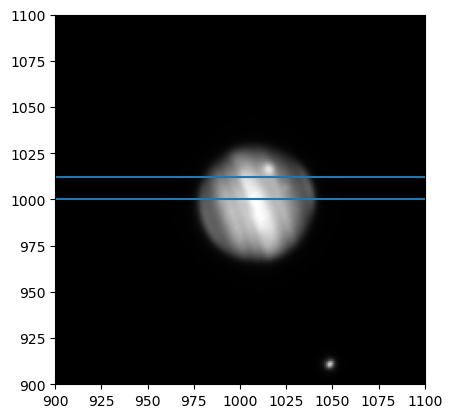

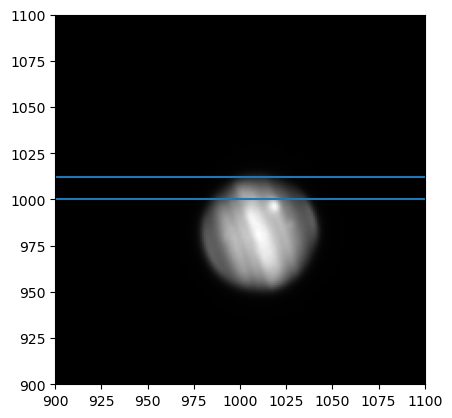

<Figure size 640x480 with 0 Axes>

In [107]:
def example_background(data):
    bkg_estimator = Background2D(data, (50, 50), filter_size=(5, 5), bkg_estimator=MedianBackground())
    median_background = bkg_estimator.background_median
    return median_background

# now to make our science images
finals = []
raws = lights
for raw in raws:
    hdul = fits.open(raw)
    data = hdul[0].data # Append the data to the list
    header = hdul[0].header
    print(header["DATE-OBS"])
    hdul.close()
    data = data.astype(np.float64)
    data -= master_dark3
    data /= master_flat
    background = example_background(data)
    data -= background
    finals.append(data)
    

for final in [finals[1],finals[6]]:
    plt.imshow(final, cmap = 'gray')
    plt.axhline(1012)
    plt.axhline(1000)
    plt.xlim(900, 1100)
    plt.ylim(900, 1100)
    plt.figure()

In [105]:
# lets save one of our finals
final = finals[0]
data_to_save = final
hdu = fits.PrimaryHDU(data_to_save)
hdul = fits.HDUList([hdu])
hdul.writeto('FINAL.fits', overwrite=True)
hdul.close()

# Option 2: Transient - Nova

The science goal is to determine the varying flux of a transient-like event in the sloan-$g$ and sloan-$r$ filters, i.e. find the brightness of this dwarf nova in the Large Magellanic Cloud at different timestamps.

To meet this science goal requires multiple observations. **Therefore there are multiple raw images you need to reduce.**
The raw and calibration files for this option are located on the macdiarmid server: ASTR211/2024_Lab_Files/Advanced_Phot_Reduction_Lab/Nova/

All data must be reduced and all problems within the data must be identified and resolved **before doing the science measurement**. 

Discuss with the tutor if you think you are done with the data reduction

</br>

**Additional exercise: hints on doing the science measurement:**


The coordinates of the target are ${\rm RA} = 74.18812_{}^{\circ}$, ${\rm DEC} = -68.55491_{}^{\circ}$. The images have been plate-solved and the non-reduced headers have been updated with this information. The zeropoint for a perfectly calibrated field has been calculated and is provided in the header for use in aperture photometry.

The science diagnostics are:
- The magnitude against Modified Julian Date (MJD).
- The flux (in units of micro-Jansky's) against Modified Julian Date (MJD).

Potentially useful equations:
- MJD = JD - 2400000.5
- $m = -2.5 \log_{10}(f_{\rm Jy}^{}) + 8.9$
- $ = \delta f_{\rm Jy}^{} = 0.4 \ln(10) \times 10^{(8.9-m)/2.5} \times \delta m$

</br></br>

---

## Option 3: Star Cluster - 47 Tuc

The science goal is to determine the age of the stellar cluster by comparing the CMD of the cluster in sloan-$g$ and sloan-$i$ filters to isochrones.

To meet this science goal requires multiple observations. **Therefore there are multiple raw images you need to reduce.**
The raw and calibration files for this option are located on the macdiarmid server: ASTR211/2024_Lab_Files/Advanced_Phot_Reduction_Lab/Cluster/

All data must be reduced and all problems within the data must be identified and resolved **before doing the science measurement**. 

Discuss with the tutor if you think you are done with the data reduction

</br>

**Additional exercise: hints on doing the science measurement:**

Use the crowded field exercise in Lab 2 to determine the flux for each of the stars in the field of view for both filters. 

The science diagnostics are:
- CMD of 47 Tuc
- Isochrone overlay on CMD of 47 Tuc

Potentially useful resources:
- Geneva Stellar evolution tracks: https://www.unige.ch/sciences/astro/evolution/en/database/syclist/

</br></br>

---

# Option 4: Galaxy Morphology - NGC1300

The science goal is to find where the oldest stars are situated in the galaxy by determining the flux of the galaxy in the sloan-$g$, sloan-$r$, sloan-$i$ filters. 

To meet this science goal requires multiple observations. **Therefore there are multiple raw images you need to reduce.**
The raw and calibration files for this option are located on the macdiarmid server: ASTR211/2024_Lab_Files/Advanced_Phot_Reduction_Lab/Galaxy/

All data must be reduced and all problems within the data must be identified and resolved **before doing the science measurement**. 

Discuss with the tutor if you think you are done with the data reduction.

</br>

**Additional exercise: hints on doing the science measurement:**

Compare the flux through the different filters across the galaxy using apertures or cross-sections (slices). Normalise the flux in each filter to compare the contribution from the different sources. Older stars are redder, younger stars are bluer.

</br></br>

---

# Option 5: Comet - C\2019-E3

The science goal is to determine the rate of motion for the comet C\2019-E3 using the sloan-$g$, sloan-$r$, and sloan-$i$ filters. 

To meet this science goal requires multiple observations. **Therefore there are multiple raw images you need to reduce.**
The raw and calibration files for this option are located on the macdiarmid server: ASTR211/2024_Lab_Files/Advanced_Phot_Reduction_Lab/Comet/

All data must be reduced and all problems within the data must be identified and resolved **before doing the science measurement**. 

Discuss with the tutor if you think you are done with the data reduction

</br>

**Additional exercise: hints on doing the science measurement:**

To measure the rate of motion find the change in position of the comet on the sky between multiple images at different timestamps. The theoretical rate of motion is 0.00564222332 ${\rm arcseconds}/{\rm second}$.

The coordinates of the target are ${\rm RA} = 03\:\:54\:\:59.35$, ${\rm DEC} = -77\:\:24\:\:35.8$ on the 21st of November 2023 12:25 UTC. The plate-scale for these particular images is approximately 24.6162 ${\rm arcminutes}^2$. Expect some uncertainty in position estimates.

Note that these images are not plate-solved, i.e. no World-Coordinate System has been applied. You will need to use a finding chart (https://astro.swarthmore.edu/transits/finding_charts.cgi) to find the comet, which may be hard to spot.


</br></br>

---


